# 05 — Variant 5: Pix2Pix + global discriminator

Replaces the 70×70 PatchGAN (variant 2) with a global discriminator that outputs
a single real/fake scalar per image. All other hyper-parameters are identical to
variant 2 — this isolates the contribution of patch-level adversarial signal.

**Checkpoint comparison rationale**: same as variant 2 — `val_l1` biases `best.pt`
toward desaturated outputs; `last.pt` reflects the full adversarial training.

In [1]:
import sys
sys.path.append("..")

import json
from pathlib import Path

import torch
from torch.utils.data import DataLoader

from src.data import AnimeColorizationDataset
from src.training import Pix2PixTrainer
from src.utils import seed_everything, plot_loss_curves, qualitative_grid_compare, metrics_bar_chart, evaluate_model

seed_everything(42)

DATA_ROOT = Path("../data/anime_colorization")
CKPT_DIR  = Path("../checkpoints/05_pix2pix_global_disc")
FIG_DIR   = Path("../results/figures")
TABLE_DIR = Path("../results/tables")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Keep in sync with scripts/train_05_pix2pix_global_disc.py
CONFIG = dict(
    image_size=256,
    batch_size=16,
    num_workers=12,
    epochs=100,
    lr=2e-4,
    lambda_l1=100.0,
    lambda_gan=1.0,
    lambda_perceptual=0.0,
    discriminator_type="global",
    early_stopping=False,
)

## Data

In [2]:
splits = {split: AnimeColorizationDataset(DATA_ROOT, split=split,
                                          image_size=CONFIG["image_size"])
          for split in ("train", "val", "test")}

train_loader = DataLoader(splits["train"], batch_size=CONFIG["batch_size"],
                          shuffle=True,  num_workers=CONFIG["num_workers"],
                          pin_memory=True, drop_last=True, persistent_workers=True)
val_loader   = DataLoader(splits["val"],   batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=CONFIG["num_workers"],
                          pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(splits["test"],  batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=CONFIG["num_workers"],
                          pin_memory=True, persistent_workers=True)

for split, ds in splits.items():
    print(f"{split:5s}: {len(ds):6d} images")

train:  14224 images
val  :   1772 images
test :   1773 images


## Training

Training was run headless via `scripts/train_05_pix2pix_global_disc.py`.
This notebook only loads the resulting checkpoints for evaluation.

In [3]:
def make_trainer():
    return Pix2PixTrainer(
        train_loader=train_loader,
        val_loader=val_loader,
        checkpoint_dir=CKPT_DIR,
        lr=CONFIG["lr"],
        lambda_l1=CONFIG["lambda_l1"],
        lambda_gan=CONFIG["lambda_gan"],
        lambda_perceptual=CONFIG["lambda_perceptual"],
        discriminator_type=CONFIG["discriminator_type"],
        early_stopping=CONFIG["early_stopping"],
    )

trainer = make_trainer()
trainer.load_checkpoint("last.pt")
print(f"last.pt — epoch {trainer.epoch}/{CONFIG['epochs']} | best val_l1={trainer.best_metric:.4f}")

last.pt — epoch 100/100 | best val_l1=0.1497


## Loss curves

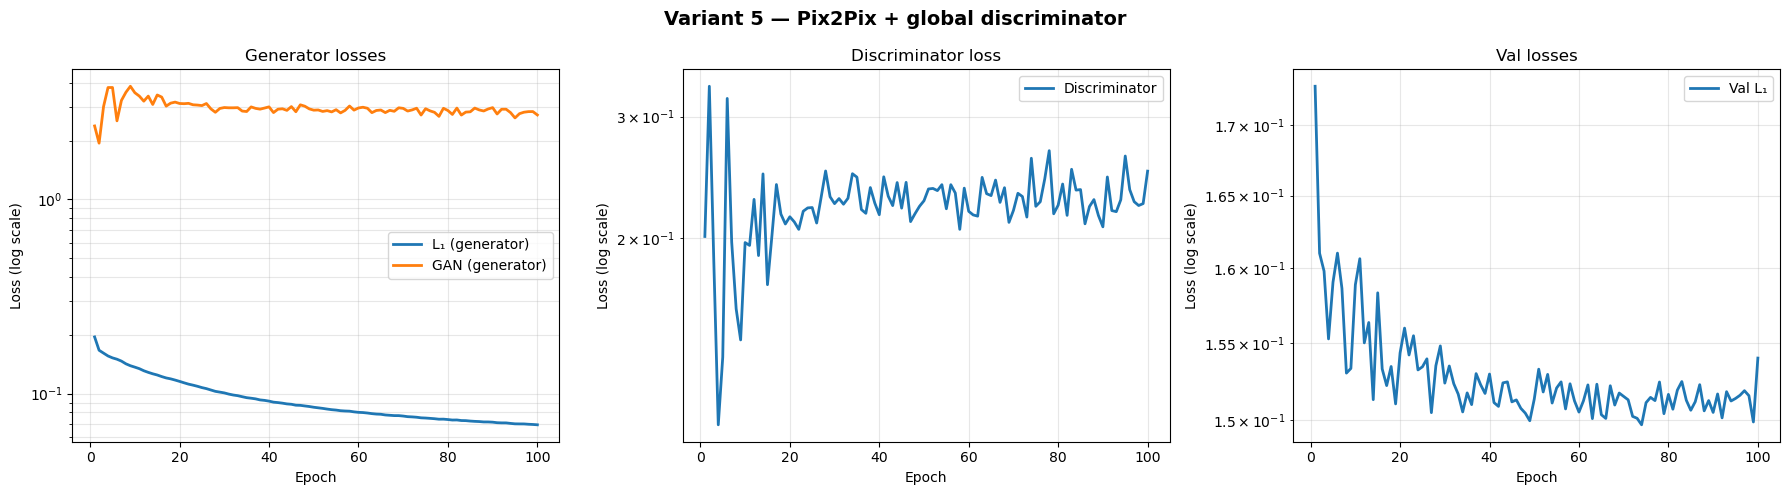

In [4]:
plot_loss_curves(trainer.history,
                 title="Variant 5 — Pix2Pix + global discriminator",
                 save_path=FIG_DIR / "05_pix2pix_global_disc_losses.png")

## Qualitative results — last.pt vs best.pt

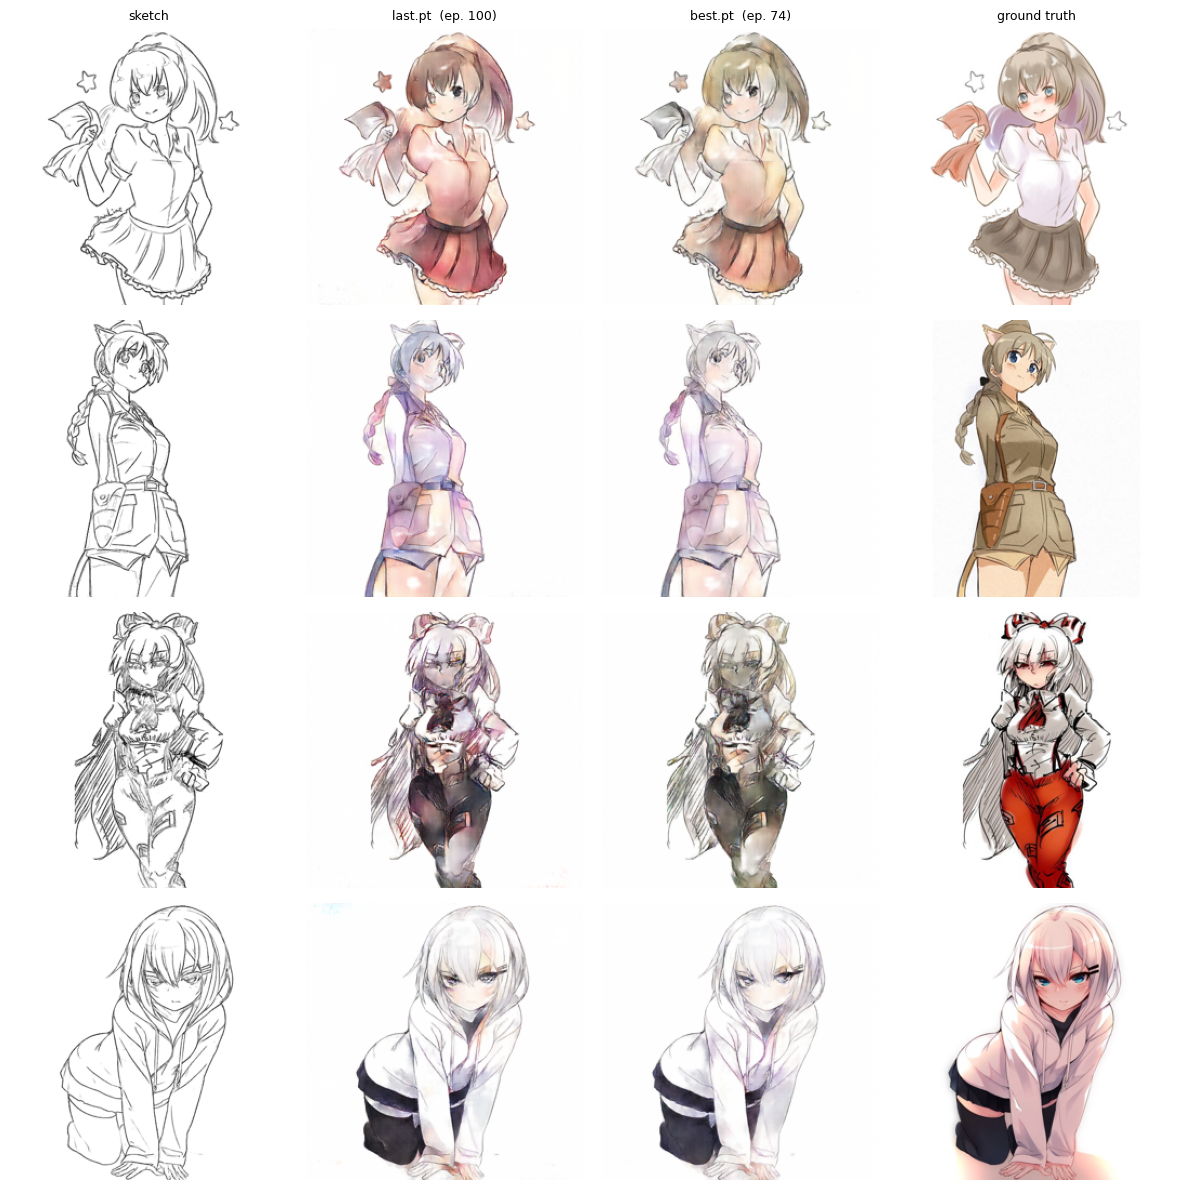

In [5]:
batch = next(iter(test_loader))

epoch_last = trainer.epoch
pred_last  = trainer.generate(batch["sketch"])

trainer.load_checkpoint("best.pt")
epoch_best = trainer.epoch
pred_best  = trainer.generate(batch["sketch"])

qualitative_grid_compare(
    batch["sketch"], pred_last, pred_best, batch["color"],
    epoch_last=epoch_last, epoch_best=epoch_best, n_rows=4,
    save_path=FIG_DIR / "05_pix2pix_global_disc_grid.png",
)

## Quantitative evaluation (test set)

/data/aidawks/conda-envs/anime-colorization/lib/python3.10/site-packages/torchmetrics/functional/image/lpips.py:332: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_

metric       last.pt     best.pt       delta
psnr         16.0662     16.2943     +0.2281
ssim          0.7923      0.7985     +0.0062
lpips         0.1942      0.1950     +0.0008
fid          45.6185     53.2963     +7.6779


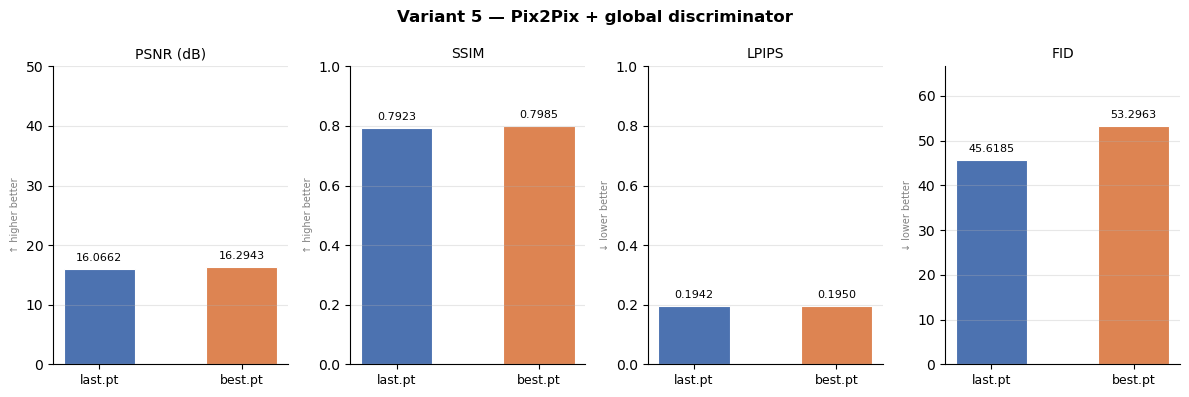

In [6]:
trainer.load_checkpoint("last.pt")
metrics_last = evaluate_model(trainer.generator, test_loader,
                              fid_dir="../results/fid/05_pix2pix_global_disc_last")

trainer.load_checkpoint("best.pt")
metrics_best = evaluate_model(trainer.generator, test_loader,
                              fid_dir="../results/fid/05_pix2pix_global_disc_best")

print(f"{'metric':8s}  {'last.pt':>10s}  {'best.pt':>10s}  {'delta':>10s}")
for k in metrics_last:
    delta = metrics_best[k] - metrics_last[k]
    print(f"{k:8s}  {float(metrics_last[k]):>10.4f}  {float(metrics_best[k]):>10.4f}  {float(delta):>+10.4f}")

metrics_bar_chart(
    {"last": metrics_last, "best": metrics_best},
    title="Variant 5 — Pix2Pix + global discriminator",
    save_path=FIG_DIR / "05_pix2pix_global_disc_metrics.png",
)

with open(TABLE_DIR / "05_pix2pix_global_disc.json", "w") as f:
    json.dump({"variant": "05_pix2pix_global_disc", "config": CONFIG,
               "metrics": {"last": metrics_last, "best": metrics_best}}, f, indent=2)